# Results Summary — Presentation Figures

**For advisor meeting: results only, no background/methods.**

Each section contains the key figure(s) and a brief interpretation. Organized as a story:
1. Multi-site cross-plots → Addis is anomalous
2. Distribution comparison → HIPS compressed at Addis
3. Multi-site wavelength analysis → Addis instrument issue confirmed
4. Seasonal patterns → structure matters
5. AERONET filtering → does it help?
6. What we've tried that didn't explain the anomaly

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import pandas as pd

CROSS_DIR = Path('output/plots/cross_plots')
WL_DIR = Path('output/plots/multisite_wavelength')
SMOOTH_DIR = Path('output/plots/smoothing_comparison')

def show_figure(path, title=None, figsize=(16, 8)):
    """Display a saved figure with optional title."""
    fig, ax = plt.subplots(figsize=figsize)
    img = mpimg.imread(str(path))
    ax.imshow(img)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    fig.tight_layout()
    plt.show()

print("Ready.")

Ready.


---
## 1. Addis Ababa Is the Anomalous Site

**Three cross-plots** (HIPS BC vs FTIR EC, Aeth vs FTIR EC, HIPS vs Aeth) across all four sites.

**Key finding**: Beijing, Delhi, and JPL show near-zero intercepts and slopes close to 1:1. Addis shows a large positive intercept (~2+ µg/m³) and compressed HIPS dynamic range. The anomaly has **two distinct co-occurring problems**: offset AND compression.

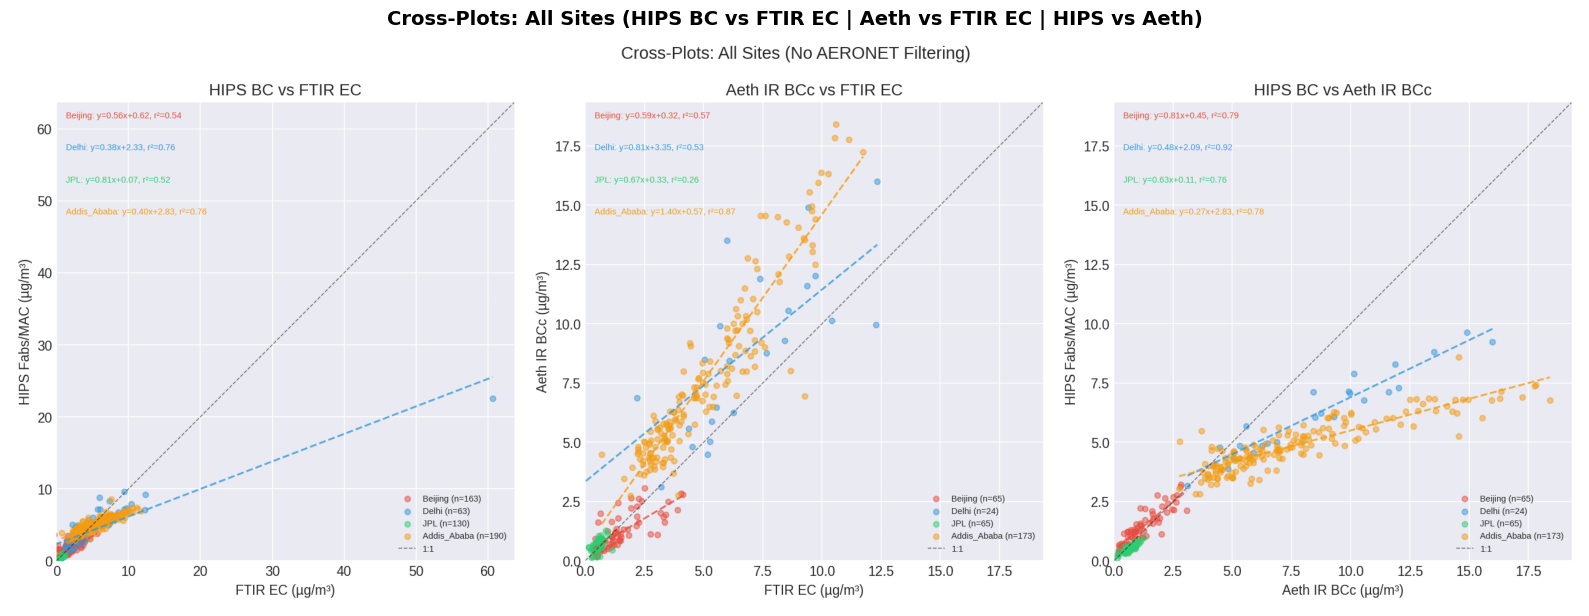

In [2]:
show_figure(CROSS_DIR / 'crossplots_all_sites_unfiltered.png',
            'Cross-Plots: All Sites (HIPS BC vs FTIR EC | Aeth vs FTIR EC | HIPS vs Aeth)')

In [3]:
# Cross-plot statistics table
stats = pd.read_csv(CROSS_DIR / 'crossplot_statistics.csv')
display(stats.round(3))

,Site,Comparison,n,Slope,Intercept,r²,x_median,y_median,x_std,y_std
0,Beijing,HIPS BC vs FTIR EC,163,0.559,0.621,0.543,1.221,1.287,0.970,0.736
1,Beijing,Aeth vs FTIR EC,65,0.588,0.321,0.566,1.271,1.075,0.997,0.778
2,Beijing,HIPS BC vs Aeth,65,0.813,0.450,0.788,1.075,1.279,0.778,0.713
3,Delhi,HIPS BC vs FTIR EC,63,0.382,2.332,0.764,3.276,3.892,7.783,3.404
4,Delhi,Aeth vs FTIR EC,24,0.810,3.345,0.529,6.035,8.620,3.037,3.381
5,Delhi,HIPS BC vs Aeth,24,0.481,2.093,0.917,8.620,6.148,3.381,1.698
6,JPL,HIPS BC vs FTIR EC,130,0.814,0.069,0.522,0.488,0.470,0.183,0.206
7,JPL,Aeth vs FTIR EC,65,0.671,0.330,0.259,0.523,0.686,0.173,0.227
8,JPL,HIPS BC vs Aeth,65,0.630,0.113,0.761,0.686,0.541,0.227,0.164
9,Addis_Ababa,HIPS BC vs FTIR EC,190,0.402,2.832,0.764,4.625,4.713,2.304,1.061


---
## 2. Distribution Comparison: HIPS Is Compressed at Addis

**Violin plots**: For Beijing/Delhi/JPL, FTIR EC and HIPS BC have comparable distributions. At Addis, HIPS BC is squeezed into a narrow range (~2–4 µg/m³) while FTIR EC and Aeth span much wider (~2–15 µg/m³).

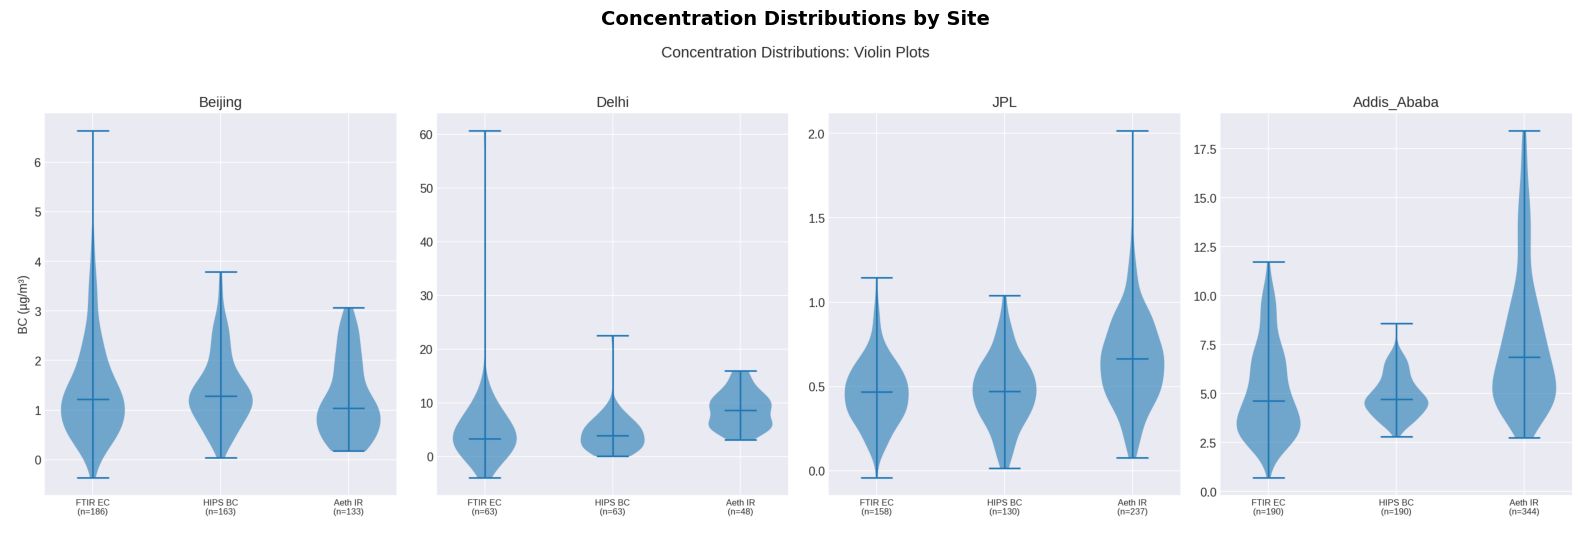

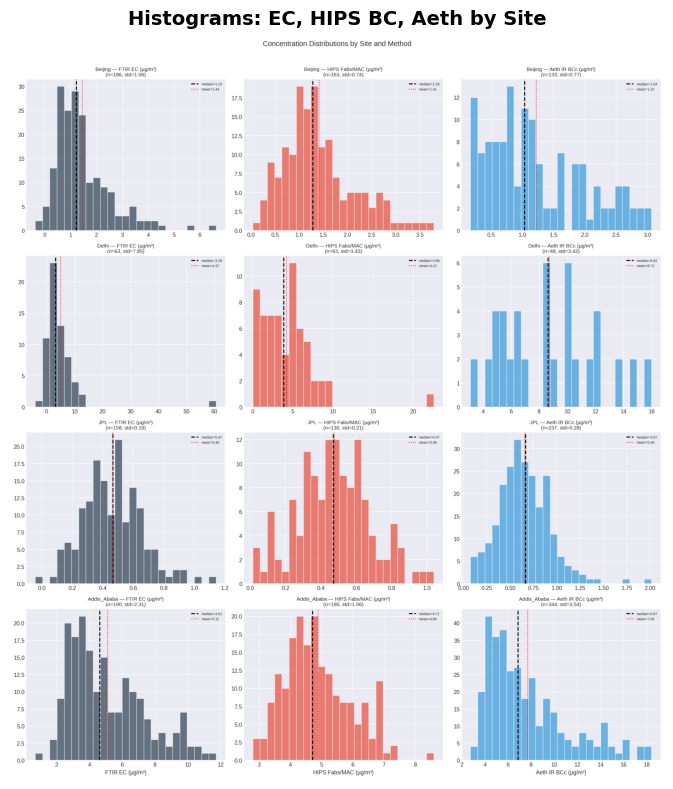

In [4]:
show_figure(CROSS_DIR / 'distributions_violin.png', 'Concentration Distributions by Site')
show_figure(CROSS_DIR / 'distributions_histogram.png', 'Histograms: EC, HIPS BC, Aeth by Site')

---
## 3. Multi-Site Wavelength Analysis: Addis Green Channel Anomaly

**The collapsed IR/Blue/Red wavelengths at Addis do NOT appear at other sites.** Green/IR ratio at Addis = 0.55 while Beijing, Delhi, JPL all show 1.05–1.15. This confirms an instrument or data processing issue specific to the ETAD MA350-0238.

The cross-site comparison panel is the key diagnostic:
- UV/IR ratio: Addis highest (~1.7), others 1.1–1.5
- Blue/IR ratio: Addis near 1.0 (collapsed), others show proper spectral separation
- AAE: all sites below literature range (eBC issue), but patterns differ by site
- Normalized Delta-C: Addis and Delhi show strongest biomass signatures

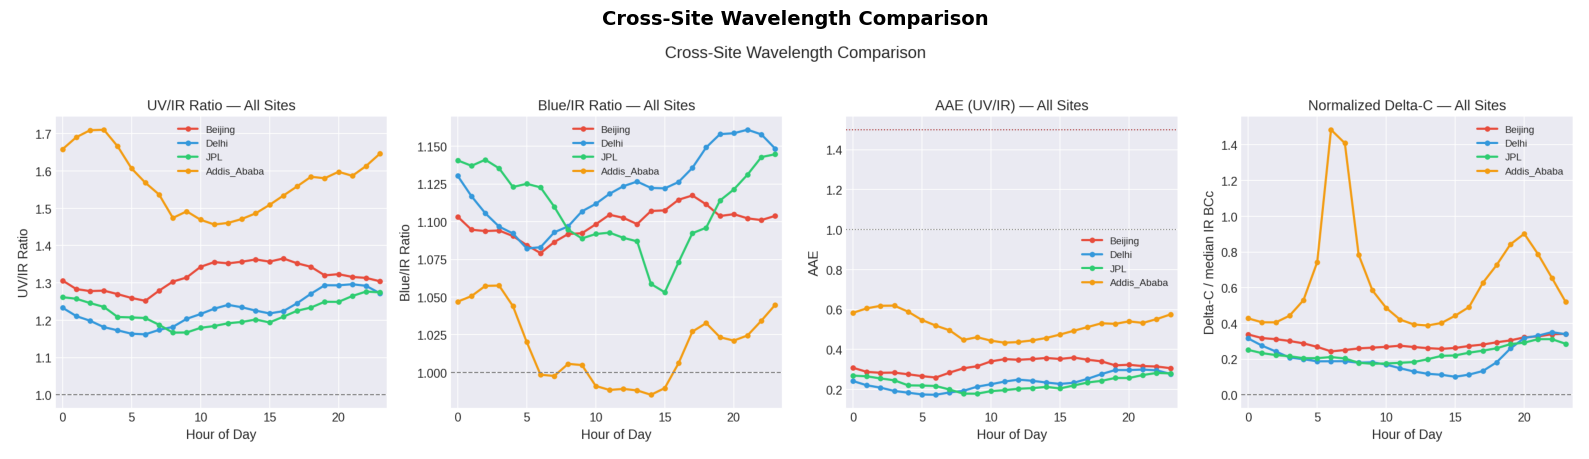

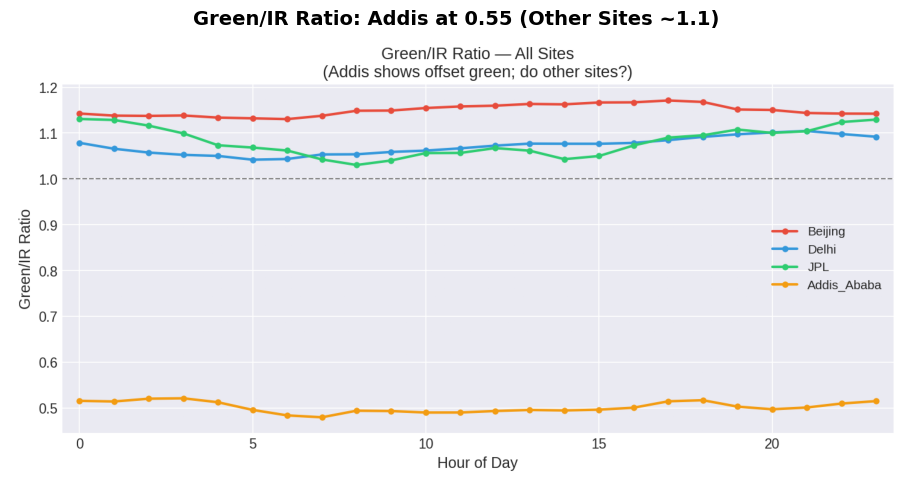

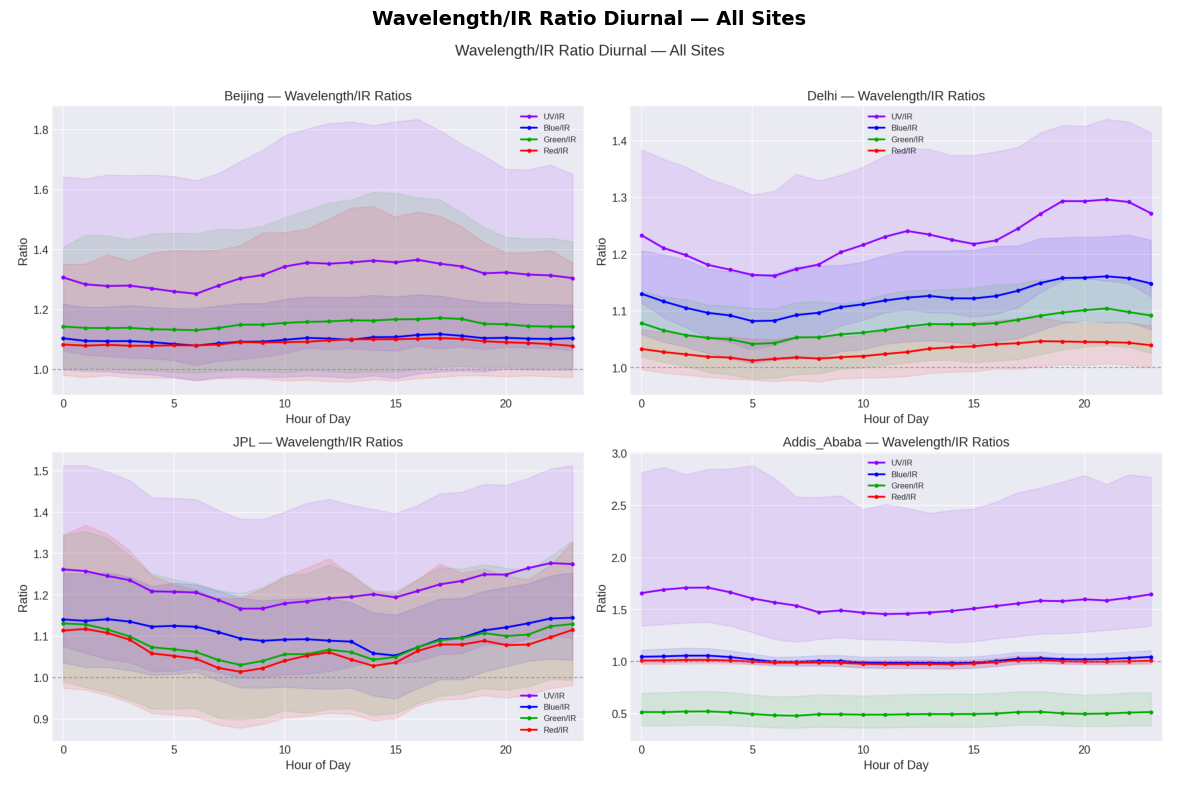

In [5]:
show_figure(WL_DIR / 'cross_site_comparison.png', 'Cross-Site Wavelength Comparison')
show_figure(WL_DIR / 'green_ir_ratio_cross_site.png', 'Green/IR Ratio: Addis at 0.55 (Other Sites ~1.1)', figsize=(12, 5))
show_figure(WL_DIR / 'ratio_diurnal_all_sites.png', 'Wavelength/IR Ratio Diurnal — All Sites')

---
## 4. Seasonal Patterns Are Essential

Aggregated data hides real structure. Key seasonal findings:
- **Delhi**: Post-monsoon (Oct) shows dramatically higher AAE and Delta-C → crop-residue burning
- **Beijing**: Winter highest AAE, summer lowest (matches Sun et al. 2022)
- **Addis**: Kiremt evening peak is distinct; dry season morning has highest UV divergence
- **JPL**: Relatively flat, lowest concentrations

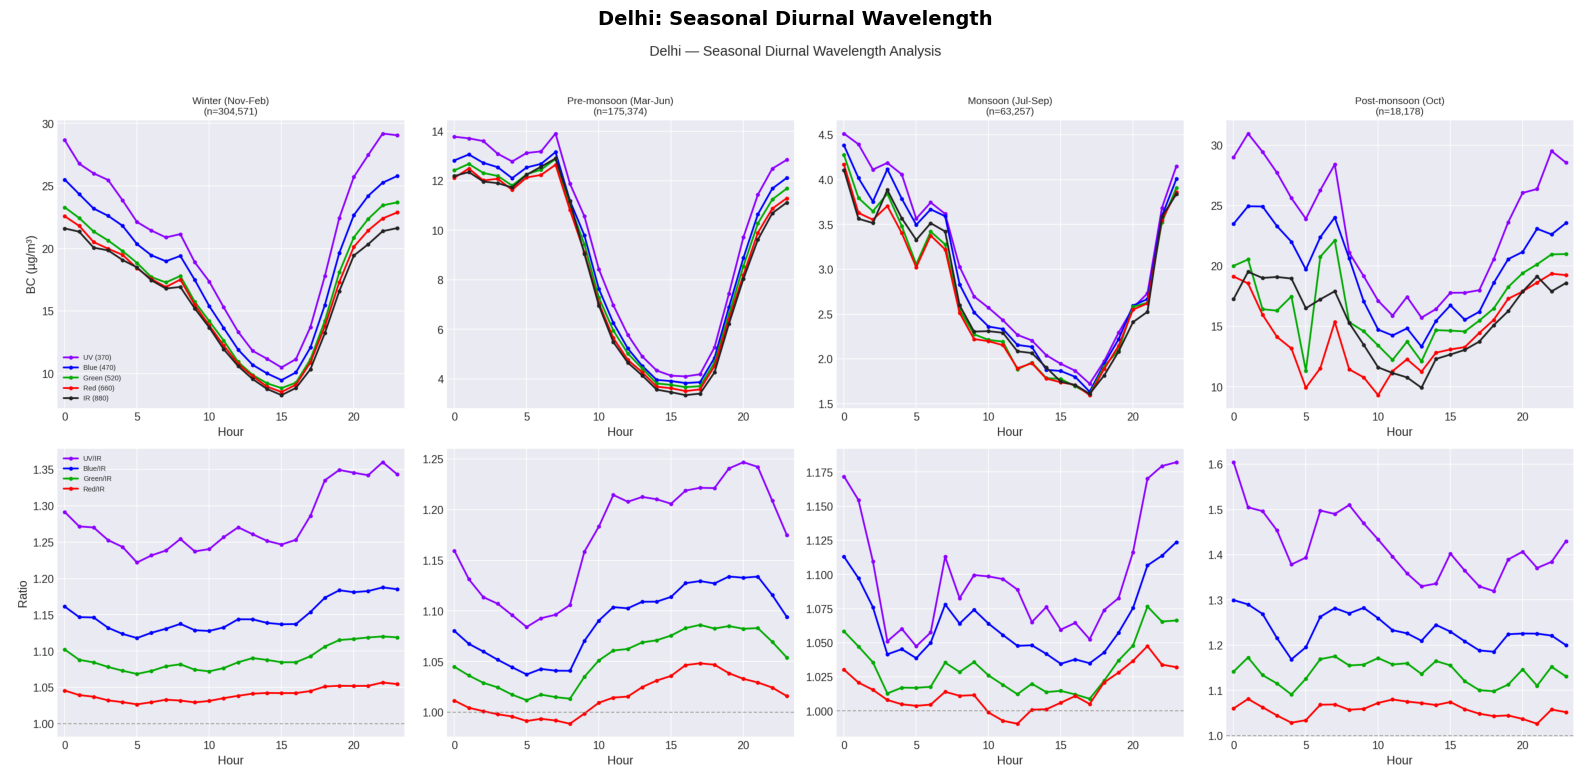

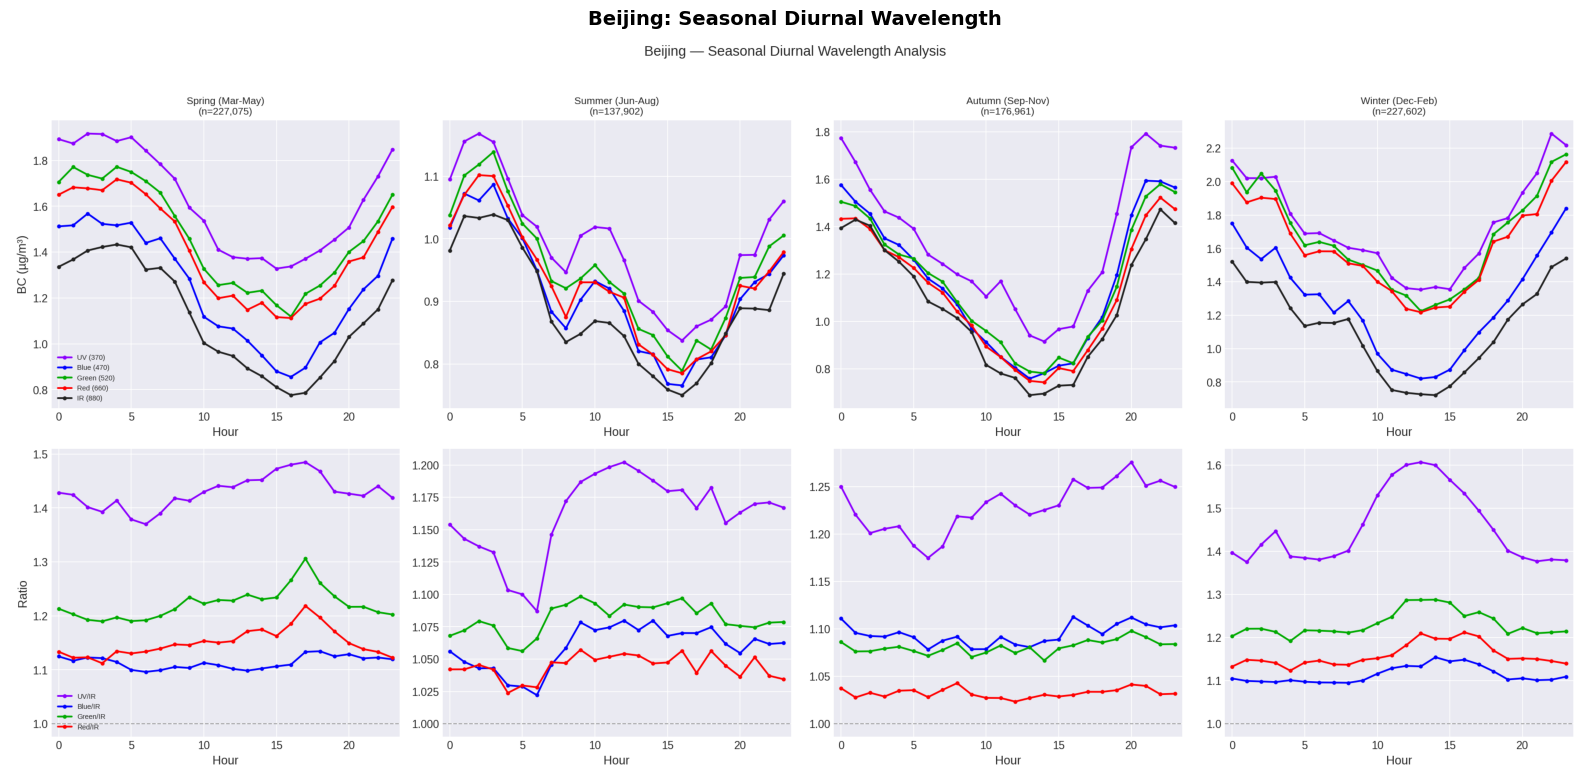

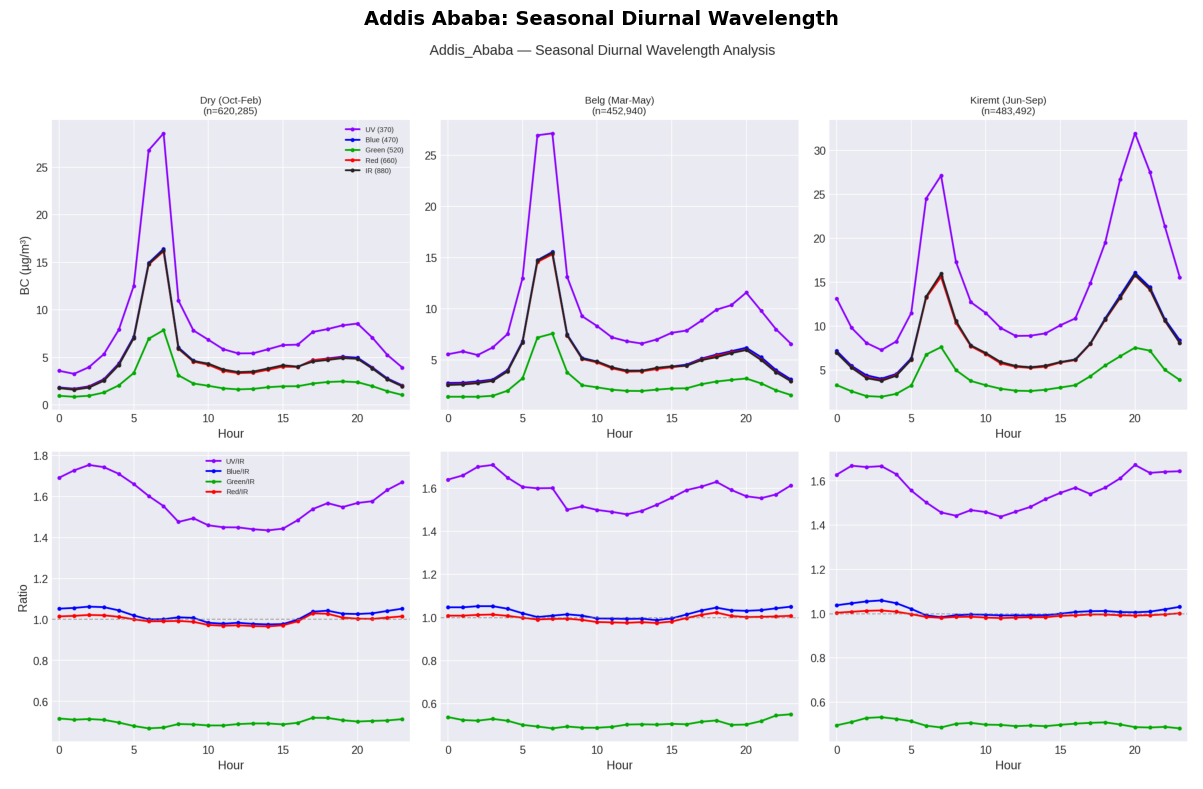

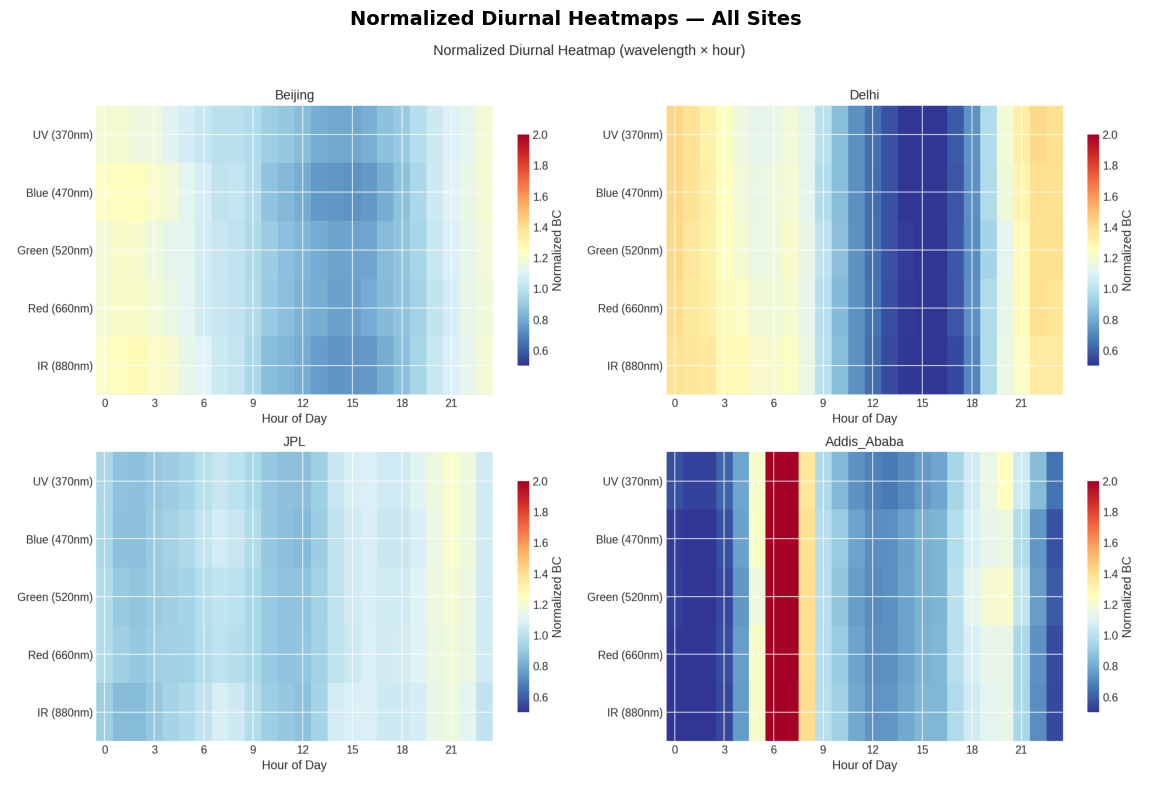

In [6]:
show_figure(WL_DIR / 'seasonal_diurnal_Delhi.png', 'Delhi: Seasonal Diurnal Wavelength')
show_figure(WL_DIR / 'seasonal_diurnal_Beijing.png', 'Beijing: Seasonal Diurnal Wavelength')
show_figure(WL_DIR / 'seasonal_diurnal_Addis_Ababa.png', 'Addis Ababa: Seasonal Diurnal Wavelength')
show_figure(WL_DIR / 'heatmap_all_sites.png', 'Normalized Diurnal Heatmaps — All Sites')

---
## 5. AERONET Filtering: Sequential Exclusion at Addis

AERONET AOD data matched with 157 Addis filter days. Removing the lowest AOD days (decoupled surface-column conditions) and observing how cross-plot relationships change at 0/20/40/60% exclusion thresholds.

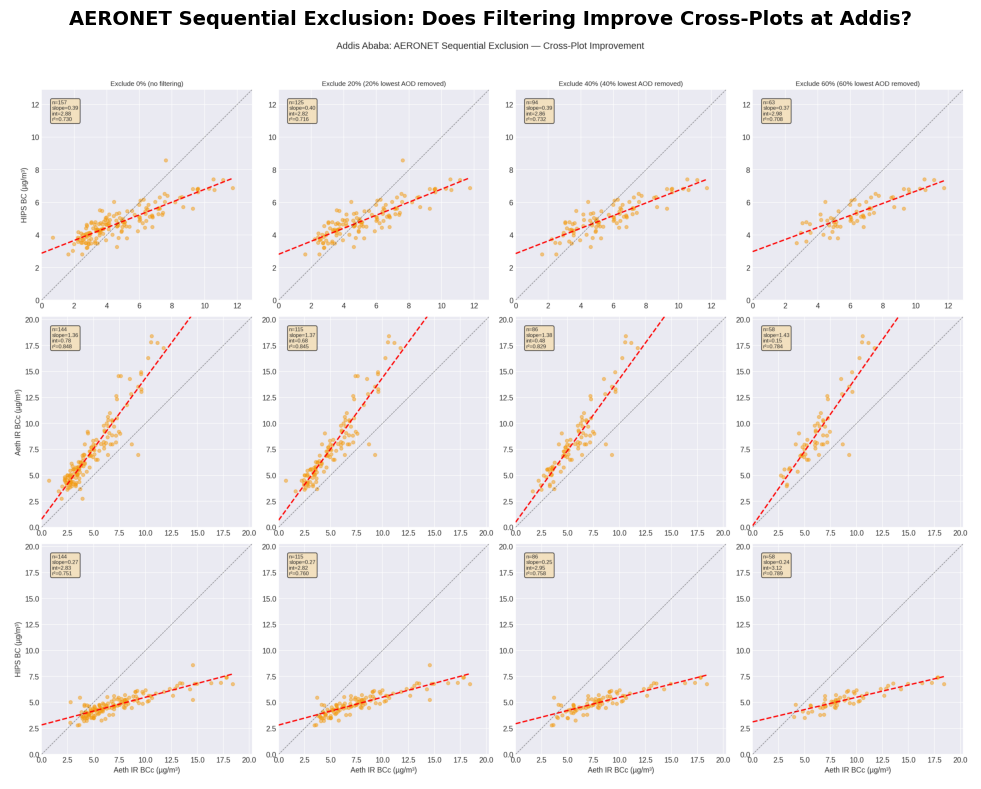

In [7]:
show_figure(CROSS_DIR / 'aeronet_sequential_exclusion.png',
            'AERONET Sequential Exclusion: Does Filtering Improve Cross-Plots at Addis?')

---
## 6. What We've Tried That Didn't Explain the Anomaly

For the Cena meeting — framed as scientific narrowing, not failure:

| Approach | Finding | Why It Didn't Work |
|----------|---------|-------------------|
| Relative humidity thresholds | Slopes converge toward 1 at high RH, but sample sizes too small | RH is a "red herring" — doesn't improve instrument comparison |
| Temperature (T_min, T_max) | Fossil fuel shows no temperature-dependent slope; biomass burning peaks when T_min is HIGHER (warmer) | Counterintuitive — burning behavior not driven by individual thermal decisions |
| Optical saturation | Quadratic vs linear fits nearly identical at Addis | No curvature = no saturation evidence ("the math doesn't support the physics word") |
| Influential point removal | Dataset too tight — no leverage points | Removing outliers doesn't change results |
| OC/EC ratio analysis | No additional insight | Didn't help explain HIPS-EC discrepancy |
| Dust interference (AERONET coarse AOD) | HIPS/FTIR ratio vs coarse AOD: r ≈ −0.33 | **Negative correlation** — higher dust → HIPS reads LOWER vs FTIR. **Rules out** dust as causing the HIPS anomaly |
| All-season aggregation | Patterns hidden | Seasonal breakdown essential (confirmed by multi-site analysis) |
| Wavelength stacking (IR≈Blue≈Red) | Unique to Addis, Green at 0.55×IR | Likely instrument/processing issue on MA350-0238, not aerosol physics |

**Key insight from dust analysis**: The negative HIPS/FTIR ratio vs coarse AOD correlation (r ≈ −0.33) means that on dusty days, HIPS **underestimates** relative to FTIR. If dust were causing the HIPS anomaly, we'd expect the opposite (dust absorbing at HIPS wavelength → HIPS overestimates). The fact that it goes the other way argues against dust as the explanation and suggests the anomaly has a different root cause — potentially related to the HIPS measurement itself or filter loading effects at high BC concentrations unique to Addis.

---
## 7. Open Questions for Cena Meeting

1. **Green channel at 0.55×IR**: Is this a known issue with the MA350-0238 at Addis? Is there a correction or recalibration available?
2. **AAE from eBC vs b_abs**: All sites show AAE well below literature range (0.15–0.63 instead of 1.0–2.0). Is this because the data is eBC (MAC-corrected) rather than raw absorption coefficients? Raw ATN columns exist and could be used.
3. **HIPS anomaly root cause**: We've ruled out dust, optical saturation, humidity, and temperature. Is there something about the filter loading, filter matrix, or analytical procedure that's different for Addis samples?
4. **Seasonal wavelength data for other sites**: Can we get the same minute-resolution data for Delhi and Beijing that we have for Addis to extend the seasonal wavelength analysis?